<a href="https://colab.research.google.com/github/Kavee486/Gold_Stock_Price_Prediction/blob/main/Gold_Stock_Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **GOLD PRICE PREDICTION**

Group No-27

Student Name- Dilmini P.V.T.
Student RegNo-EG/2021/4481


Student Name-Sewvandi M.A.K.
Student RegNo-EG/2021/4808

# Introduction

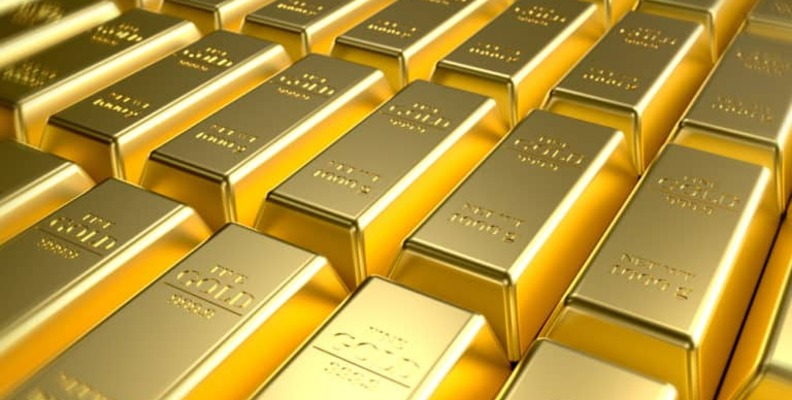

The primary goal of this project is to analyze historical gold prices and develop predictive models that can forecast future trends in gold prices. Gold is a critical asset in financial markets and has been a reliable indicator of economic stability. By leveraging a comprehensive dataset of daily gold prices from January 19, 2014, to January 22, 2024, this project aims to uncover patterns, trends, and insights that can aid analysts, traders, and researchers in understanding market behavior.

The dataset, sourced from Nasdaq, includes essential financial metrics such as opening, closing, high, and low prices, along with trading volume. This makes it a valuable resource for examining the dynamic nature of gold prices over the years and understanding factors that influence these fluctuations.

The project involves conducting exploratory data analysis to identify trends, patterns, and correlations within the data. It also includes thorough data preprocessing, ensuring the dataset is clean and well-prepared by addressing missing values and engineering relevant features. Using predictive modeling techniques such as Linear Regression and Random Forest, the project will aim to accurately forecast future gold prices. The models' performance will be rigorously evaluated using metrics such as Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R-squared (R²) to determine their effectiveness. Finally, the analysis will delve into market behavior and the impact of external factors, providing actionable insights and recommendations that could guide trading and investment strategies.

This comprehensive approach not only seeks to achieve accurate price forecasting but also to contribute to a better understanding of the complexities surrounding gold price trends, making it a valuable tool for financial analysts and investors alike.

# Literature Survey



*   Introduction of Gold Stock Price

Gold price prediction holds significant importance in finance due to gold's role as a safe-haven asset and a hedge against economic uncertainties. Investors and policymakers closely monitor gold prices to manage risks during inflation, currency fluctuations, and geopolitical tensions. Accurate predictions allow traders to make informed decisions about portfolio diversification and investment timing. Additionally, gold price trends impact global markets, influencing sectors like jewelry, electronics, and central bank reserves. By forecasting price movements, financial institutions and individuals can better navigate market volatility and optimize their financial strategies.



*   Relevance of Machine Learning

It is advantageous for traders to predict gold stock prices based on past data. However, analyzing historical data and drawing conclusions about future gold price variations requires a solid understanding of mathematics. By using machine learning, we can analyze large datasets and capture non-linear relationships, making it a more robust approach to forecasting gold prices compared to traditional statistical methods.


Research on gold price forecasting based on lstm and linear
regression https://www.shs-conferences.org/articles/shsconf/pdf/2024/01/shsconf_icdeba2023_02005.pdf








# Dataset Description




The data set used in our project is the 'Gold Stock Prices' dataset, sourced from Kaggle, which contains daily historical gold prices from 19th January of 2014 to 22nd January of 2024. The  key variables are Date, closing price, opening price, lowest recorded price  and highest recorded price. This dataset provides the necessary granularity to train predictive models effectively.

Date: A unique date for each trading day recorded.

*   Date :A unique date for each trading day recorded
*   Close:The closing price of gold on the relevant date
*   Volume: Gold trading volume on the relevant date
*   Open: The opening price of gold on the relevant date
*   High: The highest recorded price of gold during the trading day
*   Low: The lowest price recorded for gold in the trading day


[Dataset Link](https://www.kaggle.com/datasets/sahilwagh/gold-stock-prices?resource=download&select=goldstock+v1.csv)















# **Explolatory Data Analysis  and Data Pre processing**

In [ ]:
# Import necessary libraries for data manipulation, visualization, and machine learning
import numpy as np                    # For numerical operations, especially with arrays and matrices
import pandas as pd                   # For data manipulation and analysis, especially DataFrames
import matplotlib.pyplot as plt       # For creating static, animated, and interactive visualizations
import seaborn as sns                 # For statistical data visualization, based on matplotlib
import tensorflow as tf               #imports TensorFlow and gives it the alias tf for easier access


# Import functions and classes for machine learning tasks
from sklearn.model_selection import train_test_split   # For splitting the dataset into training and testing sets
from sklearn.ensemble import RandomForestRegressor     # For using the Random Forest algorithm on regression tasks
from sklearn import metrics                            # For evaluating model performance (e.g., mean absolute error, R-squared
from scipy.stats import pearsonr                       # For calculating the Pearson Correlation Coefficient
from sklearn.metrics import mean_squared_error         # For computing the Mean Squared Error (MSE)
from statsmodels.tsa.seasonal import seasonal_decompose # For analyzing seasonal patterns in time series data
from sklearn.model_selection import cross_val_score
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import MinMaxScaler
!pip install scikit-learn # Install scikit-learn
from sklearn.metrics import mean_absolute_error
from sklearn.impute import SimpleImputer

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Data collection and processing

In [ ]:

# Add the dataset into the Colab runtime and load the dataset as a Pandas dataframe.

gold_data = pd.read_csv('/content/drive/MyDrive/goldstock v1.csv')

In [ ]:
# print first 5 rows in the dataframe
gold_data.head()

NameError: name 'gold_data' is not defined

In [ ]:
# print last 5 rows of the dataframe
gold_data.tail()

,Unnamed: 0,Date,Close,Volume,Open,High,Low
2506,2528,2014-01-28,1250.5,81426.0,1254.9,1261.9,1248.0
2507,2529,2014-01-27,1263.5,63419.0,1269.9,1280.1,1252.0
2508,2530,2014-01-24,1264.5,34998.0,1264.3,1273.2,1256.9
2509,2531,2014-01-23,1262.5,41697.0,1235.1,1267.1,1230.8
2510,2532,2014-01-22,1238.6,80262.0,1240.5,1243.5,1235.5


In [ ]:
# number of rows and columns
gold_data.shape

(2511, 7)

In [ ]:
# getting some basic informations about the data
gold_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2511 entries, 0 to 2510
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  2511 non-null   int64  
 1   Date        2511 non-null   object 
 2   Close       2511 non-null   float64
 3   Volume      2511 non-null   float64
 4   Open        2511 non-null   float64
 5   High        2511 non-null   float64
 6   Low         2511 non-null   float64
dtypes: float64(5), int64(1), object(1)
memory usage: 137.4+ KB


**Missing values**

In [ ]:
# checking the number of missing values
gold_data.isnull().sum()

,0
Unnamed: 0,0
Date,0
Close,0
Volume,0
Open,0
High,0
Low,0




*   There are no any missing values in the dataset.




**Remove rows with NaN values**

In [ ]:
gold_data.dropna(inplace=True)

In [ ]:
# getting the statistical measures of the data
gold_data.describe()

,Unnamed: 0,Close,Volume,Open,High,Low
count,2511.000000,2511.000000,2511.000000,2511.000000,2511.000000,2511.000000
mean,1260.792911,1498.726085,185970.770609,1498.725528,1508.451454,1488.869932
std,729.262879,298.824811,97600.769382,299.118187,301.262244,296.417703
min,0.000000,1049.600000,1.000000,1051.500000,1062.700000,1045.400000
25%,630.500000,1249.850000,126693.500000,1249.500000,1257.300000,1242.350000
50%,1259.000000,1332.800000,175421.000000,1334.000000,1342.400000,1326.600000
75%,1888.500000,1805.850000,234832.000000,1805.600000,1815.450000,1793.050000
max,2532.000000,2093.100000,787217.000000,2094.400000,2098.200000,2074.600000


**Duplicatants Cheking**


In [ ]:
# Transpose the DataFrame so that rows become columns and columns become rows
# This is useful when checking for duplicate columns, as we want to see if any columns are identical
print(gold_data.T.duplicated())

# The duplicated() function, when applied to the transposed DataFrame, will identify duplicate columns
# It returns a Boolean Series where 'True' indicates a duplicate column (same values as another column),and 'False' indicates a unique column



Unnamed: 0    False
Date          False
Close         False
Volume        False
Open          False
High          False
Low           False
dtype: bool




*   There are no dupilicated values in the dataset.



**Univariate Analysis**

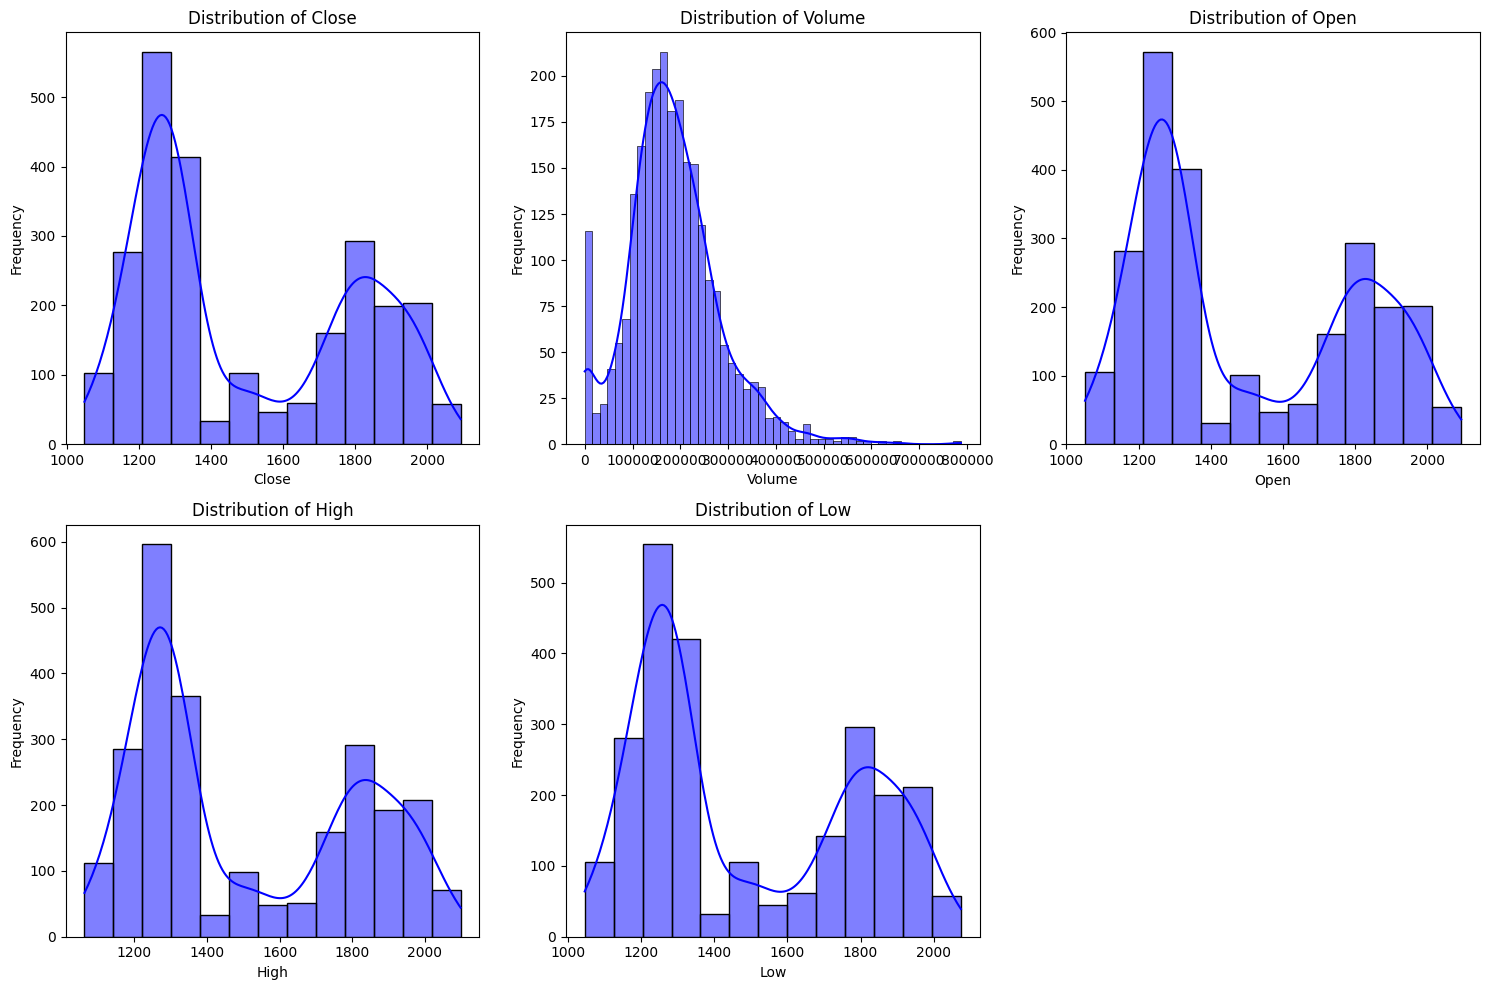

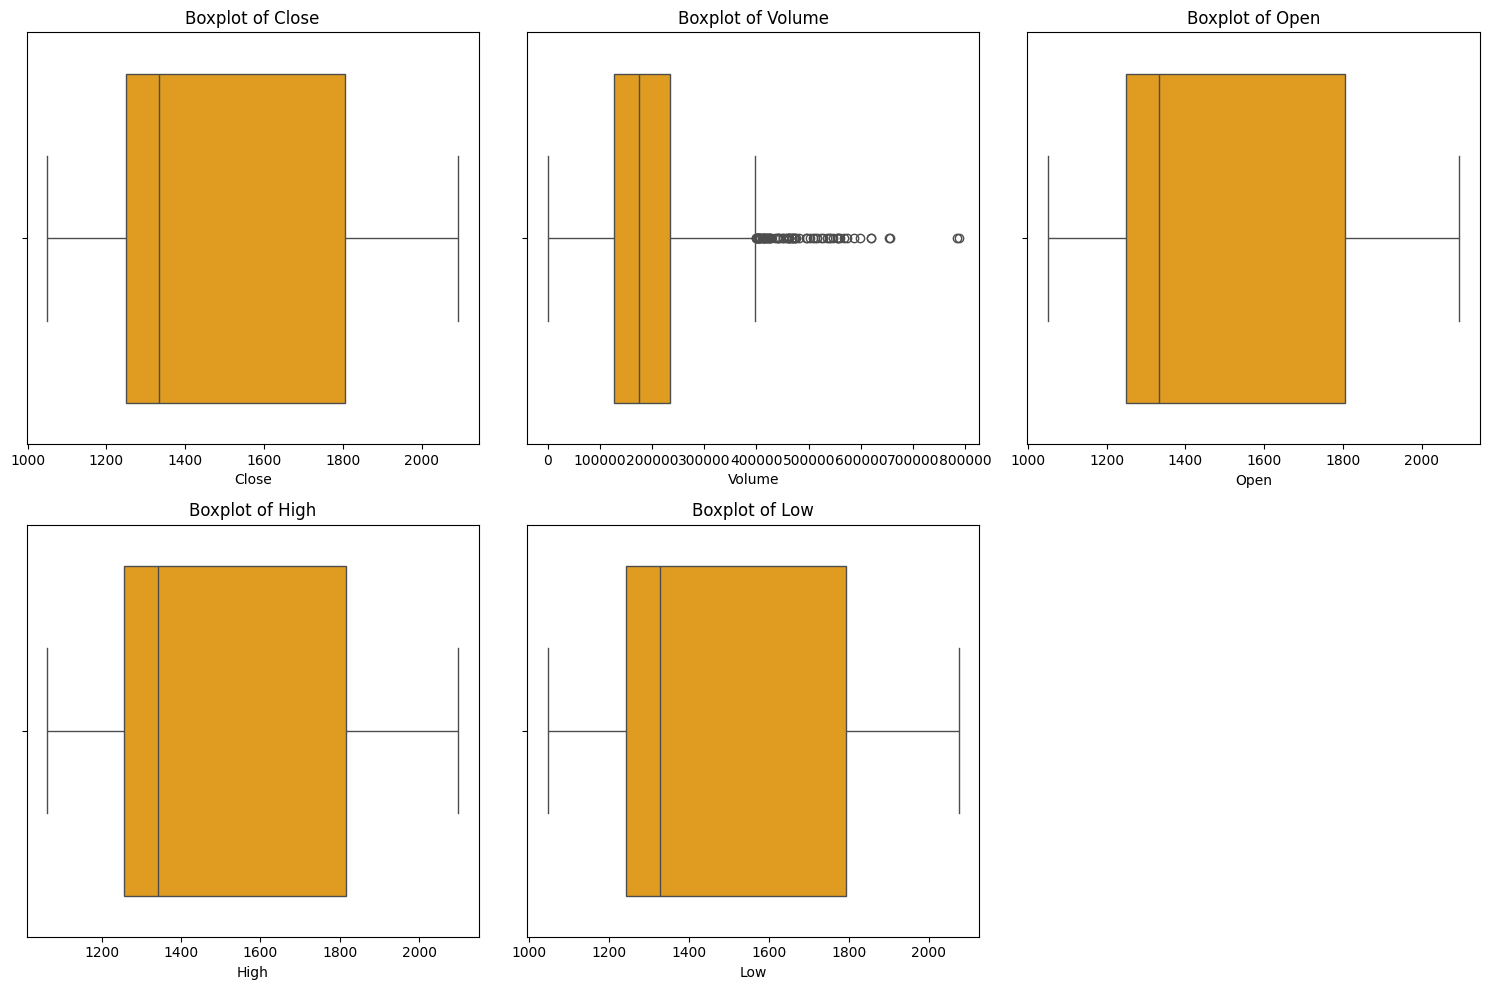

In [ ]:
# Visualizing distributions and outliers for all features in the dataset
features = ['Close', 'Volume', 'Open', 'High', 'Low']

# Plotting histograms for each feature
plt.figure(figsize=(15, 10))
for i, feature in enumerate(features, 1):
    plt.subplot(2, 3, i)  # Create a grid of subplots (2 rows, 3 columns)
    sns.histplot(gold_data[feature], kde=True, color='blue')
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# Plotting boxplots for each feature
plt.figure(figsize=(15, 10))
for i, feature in enumerate(features, 1):
    plt.subplot(2, 3, i)  # Create a grid of subplots (2 rows, 3 columns)
    sns.boxplot(x=gold_data[feature], color='orange')
    plt.title(f'Boxplot of {feature}')
plt.tight_layout()
plt.show()



**Time Series Visualization**

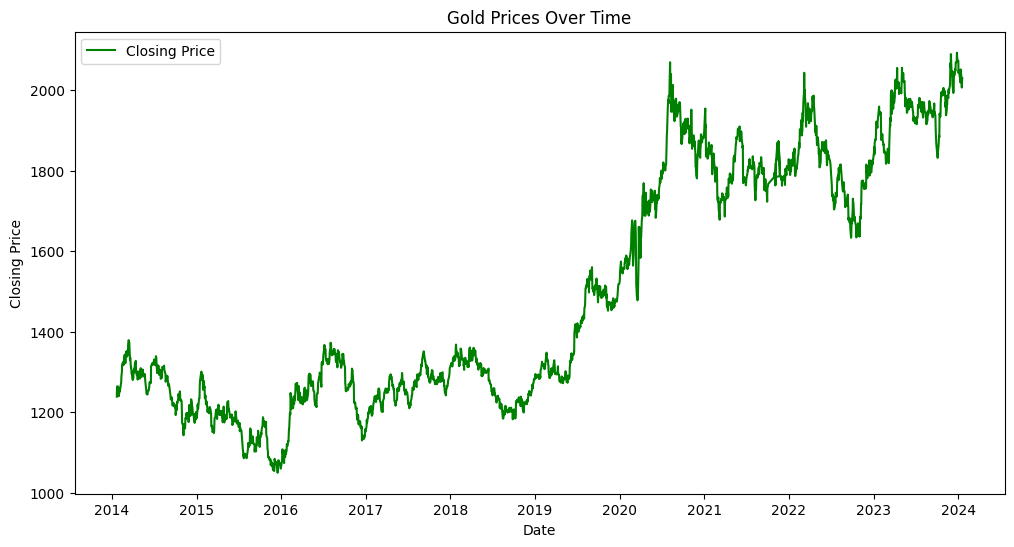

In [ ]:
# Convert 'Date' to datetime
gold_data['Date'] = pd.to_datetime(gold_data['Date'])

# Plot closing prices over time
plt.figure(figsize=(12, 6))
plt.plot(gold_data['Date'], gold_data['Close'], label='Closing Price', color='green')
plt.title('Gold Prices Over Time')
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.legend()
plt.show()

**Scatter Plot with Target Variable**

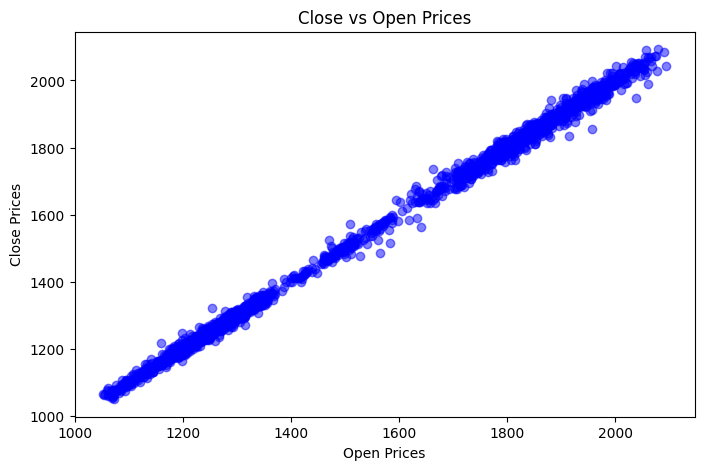

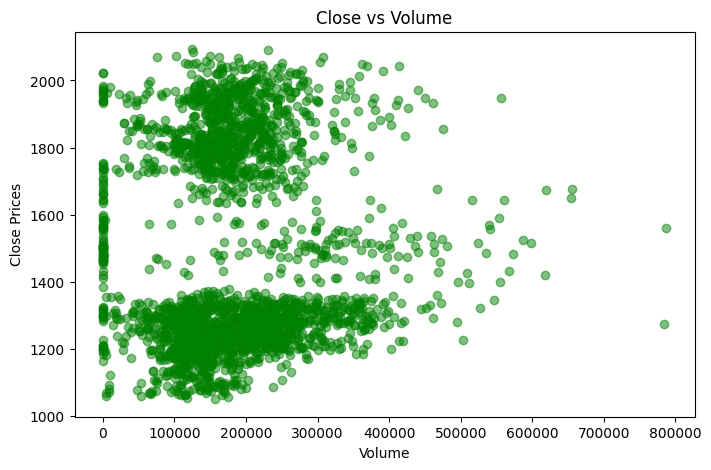

In [ ]:
# Scatter plot of 'Close' vs 'Open' prices (target vs feature)
plt.figure(figsize=(8, 5))
plt.scatter(gold_data['Open'], gold_data['Close'], alpha=0.5, color='blue')
plt.title('Close vs Open Prices')
plt.xlabel('Open Prices')
plt.ylabel('Close Prices')
plt.show()

# Scatter plot of 'Close' vs 'Volume' (target vs feature)
plt.figure(figsize=(8, 5))
plt.scatter(gold_data['Volume'], gold_data['Close'], alpha=0.5, color='green')
plt.title('Close vs Volume')
plt.xlabel('Volume')
plt.ylabel('Close Prices')
plt.show()

**Analyze Volume Trends**


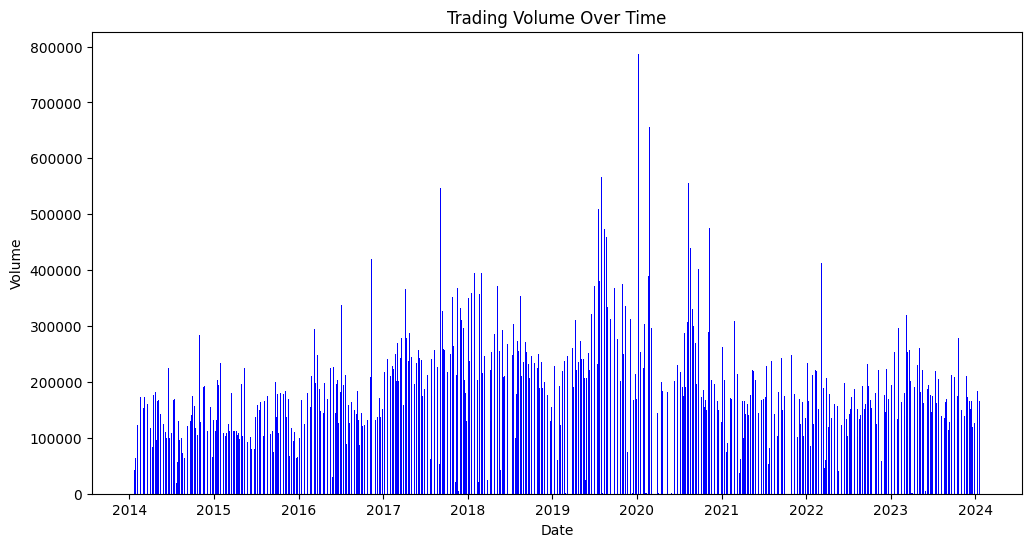

In [ ]:
# Plot volume over time
plt.figure(figsize=(12, 6))
plt.bar(gold_data['Date'], gold_data['Volume'], color='blue')
plt.title('Trading Volume Over Time')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.show()

 **Rolling Statistics**

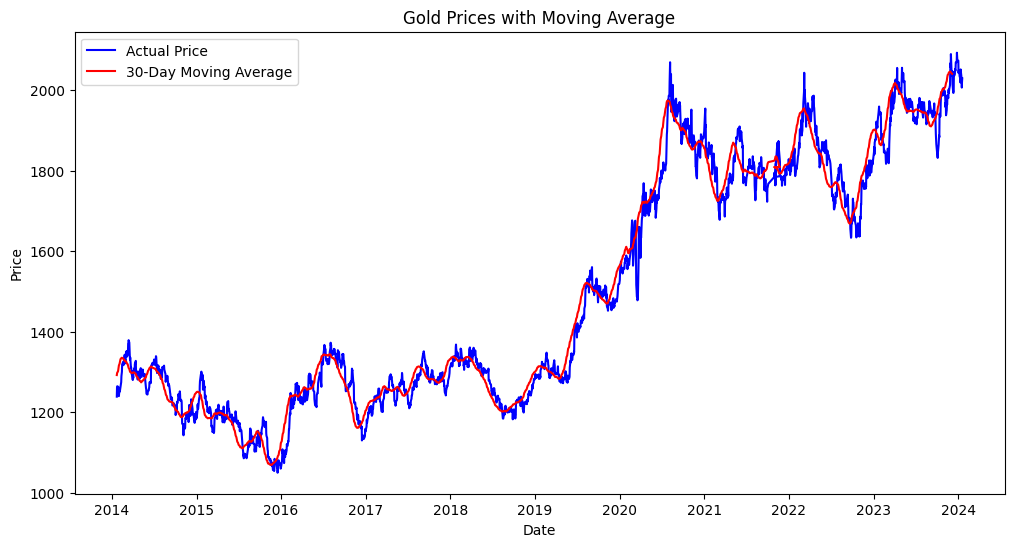

In [ ]:
# Calculate 30-day moving average
gold_data['30_MA'] = gold_data['Close'].rolling(window=30).mean()

# Plot moving average vs actual prices
plt.figure(figsize=(12, 6))
plt.plot(gold_data['Date'], gold_data['Close'], label='Actual Price', color='blue')
plt.plot(gold_data['Date'], gold_data['30_MA'], label='30-Day Moving Average', color='red')
plt.title('Gold Prices with Moving Average')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

**Seasonal and Trend Analysis**

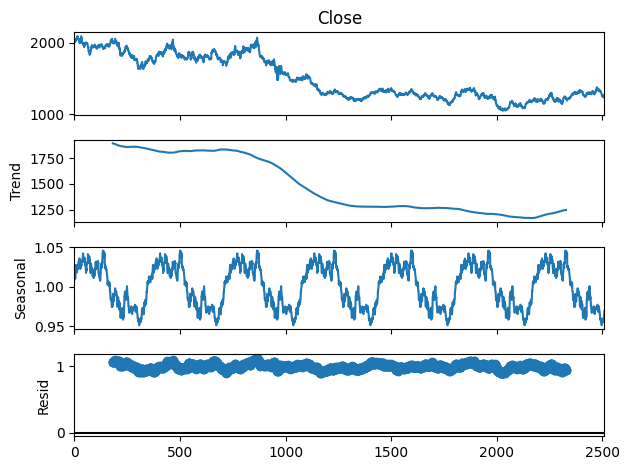

In [ ]:
# Decompose the time series
# Replace 'data' with 'gold_data'
result = seasonal_decompose(gold_data['Close'], model='multiplicative', period=365)
result.plot()
plt.show()

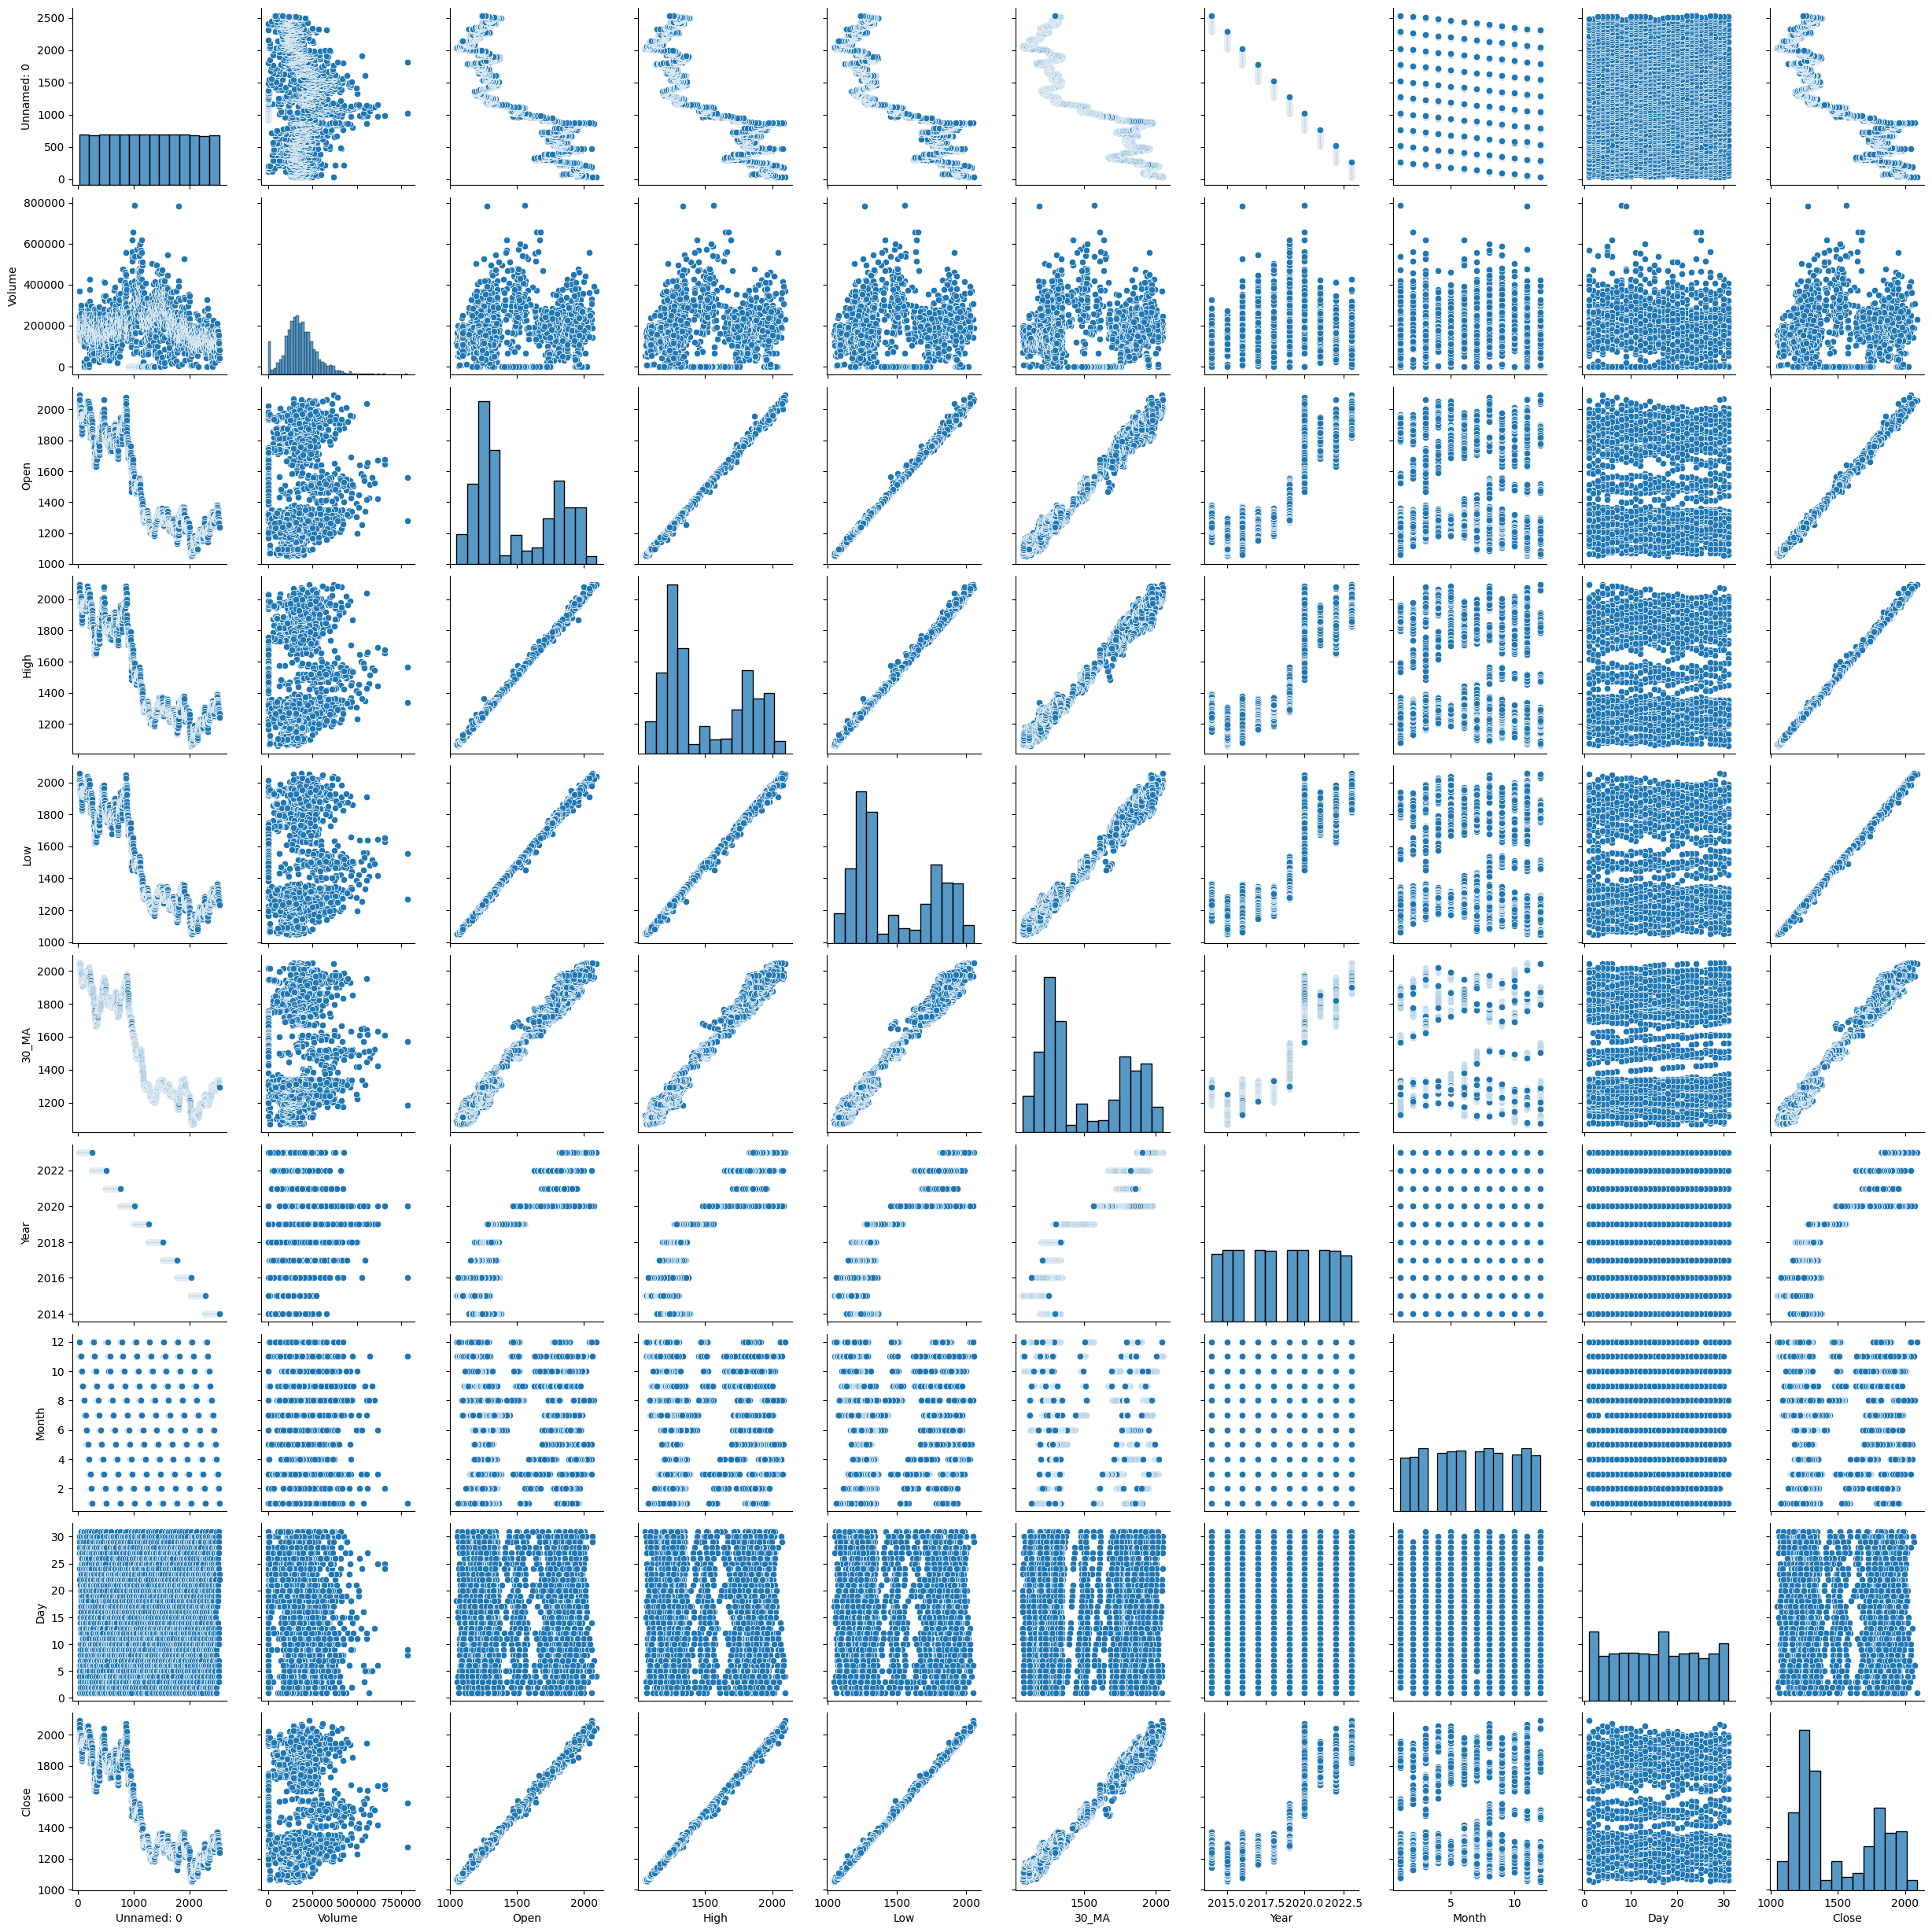

In [ ]:
# Add the target variable to the features dataframe for visualization
data_with_target = X.copy()
data_with_target['Close'] = Y

sns.pairplot(data_with_target)

**Min Max Scaling**

In [ ]:
# Assuming 'gold_data' is your DataFrame
df = pd.DataFrame(gold_data) # Replace 'data' with 'gold_data'

# Find the minimum and maximum values across the price columns
min_val = df[['Close', 'Open', 'High', 'Low']].values.min()
max_val = df[['Close', 'Open', 'High', 'Low']].values.max()

# Use these values for feature_range
scaler = MinMaxScaler(feature_range=(min_val, max_val))

# Scale Volume
df['Volume_scaled'] = scaler.fit_transform(df[['Volume']])

print(df)

      Unnamed: 0       Date   Close    Volume    Open    High     Low  \
0              0 2024-01-19  2029.3  166078.0  2027.4  2041.9  2022.2   
1              1 2024-01-18  2021.6  167013.0  2009.1  2025.6  2007.7   
2              2 2024-01-17  2006.5  245194.0  2031.7  2036.1  2004.6   
3              3 2024-01-16  2030.2  277995.0  2053.4  2062.8  2027.6   
4              4 2024-01-12  2051.6  250946.0  2033.2  2067.3  2033.1   
...          ...        ...     ...       ...     ...     ...     ...   
2506        2528 2014-01-28  1250.5   81426.0  1254.9  1261.9  1248.0   
2507        2529 2014-01-27  1263.5   63419.0  1269.9  1280.1  1252.0   
2508        2530 2014-01-24  1264.5   34998.0  1264.3  1273.2  1256.9   
2509        2531 2014-01-23  1262.5   41697.0  1235.1  1267.1  1230.8   
2510        2532 2014-01-22  1238.6   80262.0  1240.5  1243.5  1235.5   

            30_MA  Volume_scaled  
0             NaN    1267.506595  
1             NaN    1268.757037  
2             NaN 

**Convert the 'Date' column to numerical features**

In [ ]:
gold_data['Date'] = pd.to_datetime(gold_data['Date'])
gold_data['Year'] = gold_data['Date'].dt.year
gold_data['Month'] = gold_data['Date'].dt.month
gold_data['Day'] = gold_data['Date'].dt.day

**Drop the original 'Date' column**

In [ ]:
X = gold_data.drop(['Close', 'Date'], axis=1)
Y = gold_data['Close']

**Split the Data Set**

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, random_state=2)
# Split the dataset into training and testing sets
# 'X' represents the features, and 'Y' is the target variable (Close price)
# 80% of the data will be used for training, and 20% for testing.
# 'random_state=2' ensures that the split is reproducible (same result each time).


# Model Training: Random Forest Regressor

**Initializing the Random Forest Regressor model**

In [ ]:

# Initialize the Random Forest Regressor with regularization
rf = RandomForestRegressor(
    n_estimators=100,          # Number of trees
    max_depth=10,              # Limit the depth of the trees
    min_samples_split=5,       # Minimum samples to split an internal node
    min_samples_leaf=2,        # Minimum samples required in a leaf node
    max_features='sqrt',       # Consider only a subset of features for each split
    random_state=2
)

**Cross-validation with 5 folds to get the Mean Squared Error**

In [ ]:
scores = cross_val_score(rf, X, Y, scoring='neg_mean_squared_error', cv=5)
print(f'Cross-Validation MSE: {-scores.mean()}')

Cross-Validation MSE: 948.6323480709058


**Train the model**

In [ ]:
rf.fit(X_train, Y_train)

RandomForestRegressor(max_depth=10, max_features='sqrt', min_samples_leaf=2,
                      min_samples_split=5, random_state=2)

**Predictions**

In [ ]:
train_data_prediction = rf.predict(X_train)  # Prediction on training data
test_data_prediction = rf.predict(X_test)    # Prediction on testing data

# Model Evaluation


In [ ]:
# R squared error for train data set
error_score = metrics.r2_score(Y_train, train_data_prediction)
print("R squared error(Train set) : ", error_score)


# R squared error for test data set
error_score = metrics.r2_score(Y_test, test_data_prediction)
print("R squared error(Test set) : ", error_score)



R squared error(Train set) :  0.9997729099535803
R squared error(Test set) :  0.9993181945266463




*   R-Squared error represent the propotion of variance explained by the model.It shows how well the data fit the regression model.

*   R-Squared value varies between 0 to 1.
*   According to R Squared values,both Train set and test set main high performance.Therefore the model generalizes well to unseen data.




In [ ]:
#calculate Mean Absolute Error for train data set
mae = metrics.mean_absolute_error(Y_train, train_data_prediction)
print("Mean Absolute Error(Train set):", mae)


#calculate Mean Absolute Error for test data set
mae = metrics.mean_absolute_error(Y_test, test_data_prediction)
print("Mean Absolute Error(Test set):", mae)


Mean Absolute Error(Train set): 3.211360036480656
Mean Absolute Error(Test set): 5.370058242582835




*   MAE represent the average of the absolute errors between the predicted values and actual values of the closing price of gold stock.

*   A lower MAE indictes model is greate at prediction.

*   On average,the model's predictions deviate by 3.21 units from the actual values in the trainning set.

*    On unseen data,the model's prediction deviate by 5.37 units on average.

*   In the data set Close price range is varies from 1049.6 to 2093.1.Therefore considering to given rage MAE values are small.



In [ ]:
#Calculate Mean Square Error for Train set(MSE)
mse_train = metrics.mean_squared_error(Y_train, train_data_prediction)
print("Mean Square Error(Train):", mse_train)


#Calculate Mean Square Error for Test set(MSE)
mse_test = metrics.mean_squared_error(Y_test, test_data_prediction)
print("Mean Square Error(Test):", mse_test)

Mean Square Error(Train): 20.572848773621878
Mean Square Error(Test): 56.39277905184759




*   MSE represent the mean difference between actual and precticted squared value.

*   The closing price values range from 1049.6 to 2093.1.

*  The errors are relatively small compared to the range, meaning the model is reasonably accurate

     



In [ ]:
#Calculate Root Mean Square Error(RMSE) for Train set
rmse = np.sqrt(mse_train)
print("Root Mean Square Error(Train set):",rmse)


#Calculate Root Mean Square Error(RMSE) for Test set
rmse = np.sqrt(mse_test)
print("Root Mean Square Error(Test set):",rmse)

Root Mean Square Error(Train set): 4.535730235984265
Root Mean Square Error(Test set): 7.50951257085622




*   RMSE measures the square root of the average squared differences between actual and predicted values.

*   Considering that the closing price of gold stocks in the dataset varies from 1049.6 to 2093.1, and The RMSE values are relatively small.

*   This suggests that the model's predictions are reasonably accurate, indicating that the model is performing well overall.



In [ ]:
#Huber Loss for Train set
huber_loss = tf.keras.losses.huber(Y_train, train_data_prediction)
print("Huber Loss(Train):", huber_loss.numpy())


#Huber Loss for Test set
huber_loss = tf.keras.losses.huber(Y_test, test_data_prediction) # Import huber loss from tf.keras.losses
print("Huber Loss:(Test)", huber_loss.numpy()) # Convert the tensor to a numpy array to print its value

Huber Loss(Train): 2.748835070771105
Huber Loss:(Test) 4.891423401515804




*   Huber Loss combines the MSE and MAE to reduce the impact of outliers.

*   Huber Loss is less sensitive to outliers compared to MSE, indicating the model handles potential outliers reasonably well.

*   For both trainning and test sets it shows less value for Hubber Loss.

*   That shows the model is performing well within given data range.






Compare the Actual Values and Predicted Values in a Plot

In [ ]:
Y_test = list(Y_test)

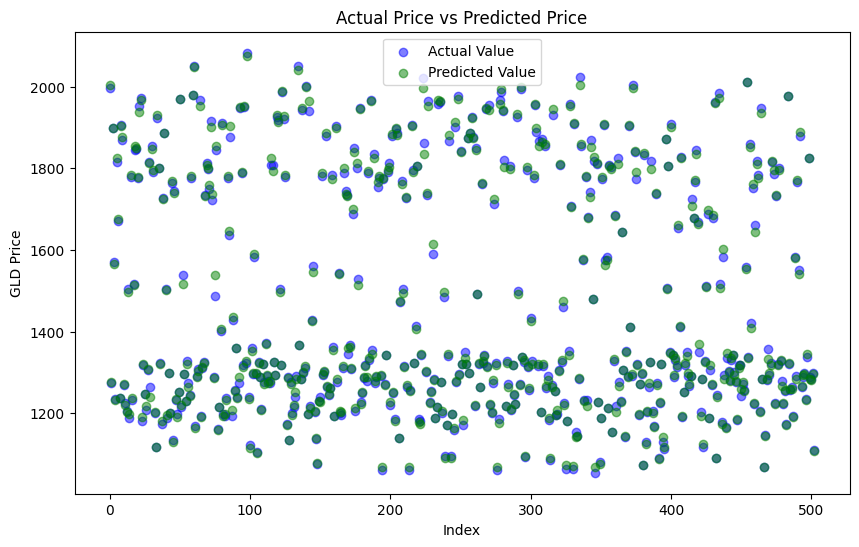

In [ ]:


# Ensure Y_test and test_data_prediction have the same length and are aligned
plt.figure(figsize=(10, 6))

# Scatter plot for better visualization
plt.scatter(range(len(Y_test)), Y_test, color='blue', label='Actual Value', alpha=0.5)
plt.scatter(range(len(test_data_prediction)), test_data_prediction, color='green', label='Predicted Value', alpha=0.5)

# Add labels and title
plt.title('Actual Price vs Predicted Price')
plt.xlabel('Index')
plt.ylabel('GLD Price')
plt.legend()
plt.show()


# Model Training: Linear Regression


**Initialize Linear regression model**

In [ ]:
# Create an imputer to replace NaN with the mean of the column
imputer = SimpleImputer(strategy='mean')  # You can also use 'median' or other strategies

# Fit the imputer on your training data and transform it
X_train_imputed = imputer.fit_transform(X_train)

# Convert the imputed data back to a DataFrame if necessary
# Assuming you have pandas imported as 'pd'
import pandas as pd  # Make sure pandas is imported
X_train_imputed = pd.DataFrame(X_train_imputed, columns=X_train.columns, index=X_train.index)

# Now, train the model using the imputed data
model.fit(X_train_imputed, Y_train)

LinearRegression()

In [ ]:
# Initialize Linear Regression model
linear_model = LinearRegression()
ridge_model = Ridge(alpha=1.0)  # Adjust alpha to control regularization strength
lasso_model = Lasso(alpha=0.1)  # Adjust alpha for Lasso

**Fit models**

In [ ]:
# Create an imputer to replace NaN with the mean of the column
imputer = SimpleImputer(strategy='mean')  # You can also use 'median' or other strategies

# Fit the imputer on your training data and transform it
X_train_imputed = imputer.fit_transform(X_train)

# Convert the imputed data back to a DataFrame if necessary
X_train_imputed = pd


**Cross Validation**

In [ ]:
# Replace NaN values with column mean
imputer = SimpleImputer(strategy="mean")
X_imputed = imputer.fit_transform(X)

# Initialize the model
linear_model = LinearRegression()

# Perform cross-validation
linear_cv_scores = cross_val_score(linear_model, X_imputed, Y, cv=5, scoring="neg_mean_squared_error")
print("Linear Model Cross-Validation MSE:", -linear_cv_scores.mean())

Linear Model Cross-Validation MSE: 33.06094850135362


In [ ]:
# Replace NaN values with column mean
imputer = SimpleImputer(strategy="mean")
X_imputed = imputer.fit_transform(X)

# Initialize the model
linear_model = LinearRegression()

# Perform cross-validation
linear_cv_scores = cross_val_score(linear_model, X_imputed, Y, cv=5, scoring="neg_mean_squared_error")
print("Linear Model Cross-Validation MSE:", -linear_cv_scores.mean())


Linear Model Cross-Validation MSE: 33.06094850135362


# Cross-validation scores for Lasso model
lasso_cv_scores = cross_val_score(lasso_model, X, Y, cv=5, scoring='neg_mean_squared_error')
print("Lasso Model Cross-Validation MSE:", -lasso_cv_scores.mean())

**Prediction**

In [ ]:
# ... your existing code for data loading and preprocessing ...

# Assuming X and Y are your features and target variable respectively:
X_train, X_test, Y_train, Y_test = train_test_split(X_imputed, Y, test_size=0.2, random_state=42) # Split data into training and testing sets

# Replace NaN values with column mean
imputer = SimpleImputer(strategy="mean")
X_imputed = imputer.fit_transform(X)

# Initialize the models
linear_model = LinearRegression()
ridge_model = Ridge() # Initialize Ridge model
lasso_model = Lasso() # Initialize Lasso model


# Fit the models before making predictions
linear_model.fit(X_train, Y_train)
ridge_model.fit(X_train, Y_train) # Fit Ridge model
lasso_model.fit(X_train, Y_train) # Fit Lasso model


# Predictions with each model
Y_train_pred_linear = linear_model.predict(X_train)
Y_test_pred_linear = linear_model.predict(X_test)

Y_train_pred_ridge = ridge_model.predict(X_train)
Y_test_pred_ridge = ridge_model.predict(X_test)

Y_train_pred_lasso = lasso_model.predict(X_train)
Y_test_pred_lasso = lasso_model.predict(X_test)


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.179e+04, tolerance: 1.793e+04
  model = cd_fast.enet_coordinate_descent(


**Model Evaluation**

In [ ]:

# Evaluation for linear model
train_accuracy_linear = r2_score(Y_train, Y_train_pred_linear)
test_accuracy_linear = r2_score(Y_test, Y_test_pred_linear)

# Evaluation for Ridge model
train_accuracy_ridge = r2_score(Y_train, Y_train_pred_ridge)
test_accuracy_ridge = r2_score(Y_test, Y_test_pred_ridge)

# Evaluation for Lasso model
train_accuracy_lasso = r2_score(Y_train, Y_train_pred_lasso)
test_accuracy_lasso = r2_score(Y_test, Y_test_pred_lasso)


In [ ]:
# Print evaluation metrics
print("Linear Model Training Accuracy:", train_accuracy_linear)
print("Linear Model Testing Accuracy:", test_accuracy_linear)
print("Ridge Model Training Accuracy:", train_accuracy_ridge)
print("Ridge Model Testing Accuracy:", test_accuracy_ridge)
print("Lasso Model Training Accuracy:", train_accuracy_lasso)
print("Lasso Model Testing Accuracy:", test_accuracy_lasso)

Linear Model Training Accuracy: 0.9996434047250649
Linear Model Testing Accuracy: 0.9996350993899062
Ridge Model Training Accuracy: 0.9996431687024101
Ridge Model Testing Accuracy: 0.9996347876155264
Lasso Model Training Accuracy: 0.9993171999061077
Lasso Model Testing Accuracy: 0.999217685914758


In [ ]:
# Calculate standard deviation of residuals
train_std_dev_linear = np.std(Y_train - Y_train_pred_linear)
test_std_dev_linear = np.std(Y_test - Y_test_pred_linear)

train_std_dev_ridge = np.std(Y_train - Y_train_pred_ridge)
test_std_dev_ridge = np.std(Y_test - Y_test_pred_ridge)

train_std_dev_lasso = np.std(Y_train - Y_train_pred_lasso)
test_std_dev_lasso = np.std(Y_test - Y_test_pred_lasso)

In [ ]:
# Print standard deviations
print("Linear Model Training Standard Deviation:", train_std_dev_linear)
print("Linear Model Testing Standard Deviation:", test_std_dev_linear)
print("Ridge Model Training Standard Deviation:", train_std_dev_ridge)
print("Ridge Model Testing Standard Deviation:", test_std_dev_ridge)
print("Lasso Model Training Standard Deviation:", train_std_dev_lasso)
print("Lasso Model Testing Standard Deviation:", test_std_dev_lasso)

Linear Model Training Standard Deviation: 5.643126810243865
Linear Model Testing Standard Deviation: 5.690711228372852
Ridge Model Training Standard Deviation: 5.6449940327610655
Ridge Model Testing Standard Deviation: 5.693352447731435
Lasso Model Training Standard Deviation: 7.8087011778749025
Lasso Model Testing Standard Deviation: 8.332139041566128


In [ ]:

# Evaluate the model
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Training metrics
train_mae = mean_absolute_error(Y_train, Y_train_pred)
train_mse = mean_squared_error(Y_train, Y_train_pred)
train_rmse = mean_squared_error(Y_train, Y_train_pred, squared=False)
train_r2 = r2_score(Y_train, Y_train_pred)

# Testing metrics
test_mae = mean_absolute_error(Y_test, Y_test_pred)
test_mse = mean_squared_error(Y_test, Y_test_pred)
test_rmse = mean_squared_error(Y_test, Y_test_pred, squared=False)
test_r2 = r2_score(Y_test, Y_test_pred)

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [ ]:
# Print evaluation metrics
print(f"Train MAE: {train_mae}")
print(f"Train MSE: {train_mse}")
print(f"Train RMSE: {train_rmse}")
print(f"Train R^2: {train_r2}")

print(f"Test MAE: {test_mae}")
print(f"Test MSE: {test_mse}")
print(f"Test RMSE: {test_rmse}")
print(f"Test R^2: {test_r2}")

Train MAE: 4.046155633874095
Train MSE: 31.951424102283674
Train RMSE: 5.652559075523552
Train R^2: 0.9996422116587652
Test MAE: 4.132502968139207
Test MSE: 32.06227095314118
Test RMSE: 5.662355601085221
Test R^2: 0.9996390008561222


# Discussion



   **Random Forest Regressor**




1.   R-Squared Error:

   Trainng: 0.99977 | Testing:0.99932

2. Error Matrices

*   MAE: Training: 3.21 | Testing: 5.37

*   MSE: Training: 20.57 |Testing: 56.39

*  RMSE: Training: 4.54 | Testing: 7.51
*  Huber Loss: Training: 2.75 | Testing: 4.89

Accordining to R-Squared values ,it indicates well performance and Errors are low ,it reflecting the model's strong prediction capabilities on both datasets.

Overrall Evaluvation:

---
Random Forest Regressor outperforms others in handling complex patterns, achieving the lowest error metrics





**Linear Regression**

1.
*   Accuracy:

 Trainning:0.999633 | Testing:0.9996332
*   Standard Deviation:

 Trainning:5.68 | Testing: 5.46

  High Accuracy indicates a strong model fit for both testing and trainning sets.The model demonstrates stable performance, with small deviations in predictions.


2. Error Matrices



 * MAE: Training: 4.08 | Testing: 3.95
 * MSE:Training: 32.30 |Testing: 29.83
 * RMSE:Training: 5.68 |Testing: 5.46



  Overrall Evaluation:

---

Linear Regression performs well, maintaining high accuracy with low variability in predictions. It is a simple yet effective model for this dataset.



**Ridge Regression**

* R-squared (Accuracy):
  Training: 0.99963 | Testing: 0.99963  


  - Observation: Very similar to base Linear Regression, with minimal overfitting.


* Standard Deviation :
 Training : 5.65 |Testing : 5.69

* Error Metrics:Similar to base Linear Regression. No significant improvement over the base model.


**Lasso Regression**

1.
* Accurancy:
 Training: 0.99930 |Testing: 0.99912

* Standard Deviation:
 Training : 7.81 |Testing : 8.33

2. Error Matrices: Higher errors compared to base Linear Regression and Ridge, making it less suitable for this dataset.





# Conclusion

Two machine learning algorithms were implemented for predicting closing price for gold stock.After evaluating the models ,

* Linear Regressor demonstrated consistent performance with high accuracy and interpretability, making it a suitable choice for simpler predictive tasks with linear relationships.

* Random Forest Regressor outperformed Linear Regression in terms of accuracy and error metrics  likely due to its ability to capture complex non-linear patterns and handle data intricacies effectively.

The Linear Regression model(or Ridge Regression) is the most suitable for this dataset due to its balance between high accuracy and low testing errors, ensuring better generalization to new data. Random Forest is a good alternative


# References

https://www.kaggle.com/code/farzadnekouei/gold-price-prediction-lstm-96-accuracy      Gold Price Prediction | LSTM | 96% Accuracy


https://www.kaggle.com/code/omarfayez/gold-price-prediction  Gold Price Prediction  by omar fayez


https://www.kaggle.com/code/joshuaswords/eda-gold-price-prediction-prophet  EDA & Gold Price Prediction [Prophet]  by Josh

In [ ]:
#@title Convert ipynb to HTML in Colab
# Upload ipynb
from google.colab import files
f = files.upload()

# Convert ipynb to html
import subprocess
file0 = list(f.keys())[0]
_ = subprocess.run(["pip", "install", "nbconvert"])
_ = subprocess.run(["jupyter", "nbconvert", file0, "--to", "html"])

# download the html
files.download(file0[:-5]+"html")


Saving Gold_Stock_Price_Prediction.ipynb to Gold_Stock_Price_Prediction.ipynb


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>